In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("simulation_results.csv")


In [5]:
metrics_df = df[df["target"] != "p"].dropna(axis=1).copy()
metrics_df.head()

,seed,family,tau,n,q,model,target,ISE,IAE,KL
0,0,clayton,0.3,100,0.1,Ordinary,r,814.489202,0.891689,0.874871
1,0,clayton,0.3,100,0.1,Ordinary,h,5423.931758,2.100428,3.880650
2,0,clayton,0.3,100,0.1,Ordinary,c,814.489163,0.089169,0.087487
3,0,clayton,0.3,100,0.1,Tail,r,12391.987640,3.308316,-1.145859
4,0,clayton,0.3,100,0.1,Tail,h,11123.469898,3.559312,-0.980998


In [6]:
p_df = df[df["target"] == "p"].dropna(axis=1).copy()
p_df.head()

,seed,family,tau,n,q,model,target,p_hat,p_true,AE,RE
6,0,clayton,0.3,100,0.100000,Ordinary,p,0.102753,0.048449,0.054304,1.120863
7,0,clayton,0.3,100,0.100000,Tail,p,0.080000,0.048449,0.031551,0.651231
14,0,clayton,0.3,500,0.044721,Ordinary,p,0.022694,0.020763,0.001931,0.092997
15,0,clayton,0.3,500,0.044721,Tail,p,0.024000,0.020763,0.003237,0.155906
22,0,clayton,0.3,1000,0.031623,Ordinary,p,0.016067,0.014524,0.001543,0.106239


In [9]:
summary = (
    metrics_df
    .groupby(["family", "tau", "n", "model", "target"], as_index=False)
    .agg(
        ISE_mean=("ISE", "mean"),
        ISE_sd=("ISE", "std"),
        IAE_mean=("IAE", "mean"),
        KL_mean=("KL", "mean"),
    )
)

summary.head(10)

,family,tau,n,model,target,ISE_mean,ISE_sd,IAE_mean,KL_mean
0,clayton,0.3,100,Ordinary,c,1297.877169,683.613874,0.098178,0.824733
1,clayton,0.3,100,Ordinary,h,6506.184794,1530.536922,2.120926,17.261471
2,clayton,0.3,100,Ordinary,r,1297.877231,683.613907,0.981778,8.247327
3,clayton,0.3,100,Tail,c,7093.293733,7493.483945,0.238325,2.254104
4,clayton,0.3,100,Tail,h,9522.167829,2264.583103,3.469160,45.044644
5,clayton,0.3,100,Tail,r,7093.294074,7493.484305,2.383254,21.008718
6,clayton,0.3,500,Ordinary,c,1780.922378,0.060145,0.043100,0.509501
7,clayton,0.3,500,Ordinary,h,8262.133459,0.272796,2.020653,24.249144
8,clayton,0.3,500,Ordinary,r,1780.922245,0.060145,0.963747,11.392781
9,clayton,0.3,500,Tail,c,1556.691419,317.277182,0.053747,0.408683


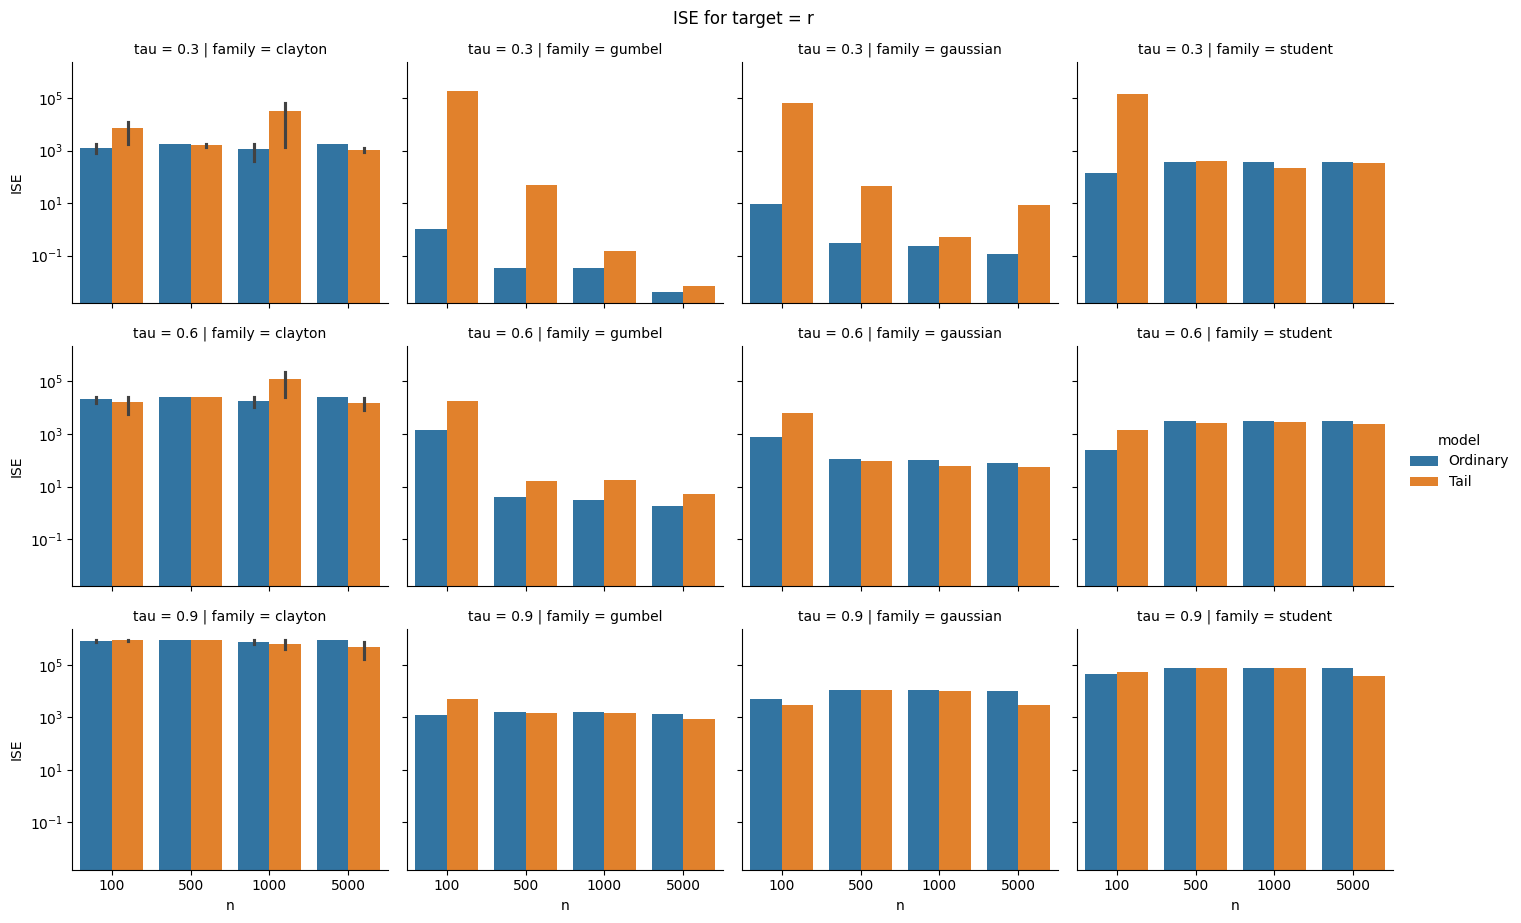

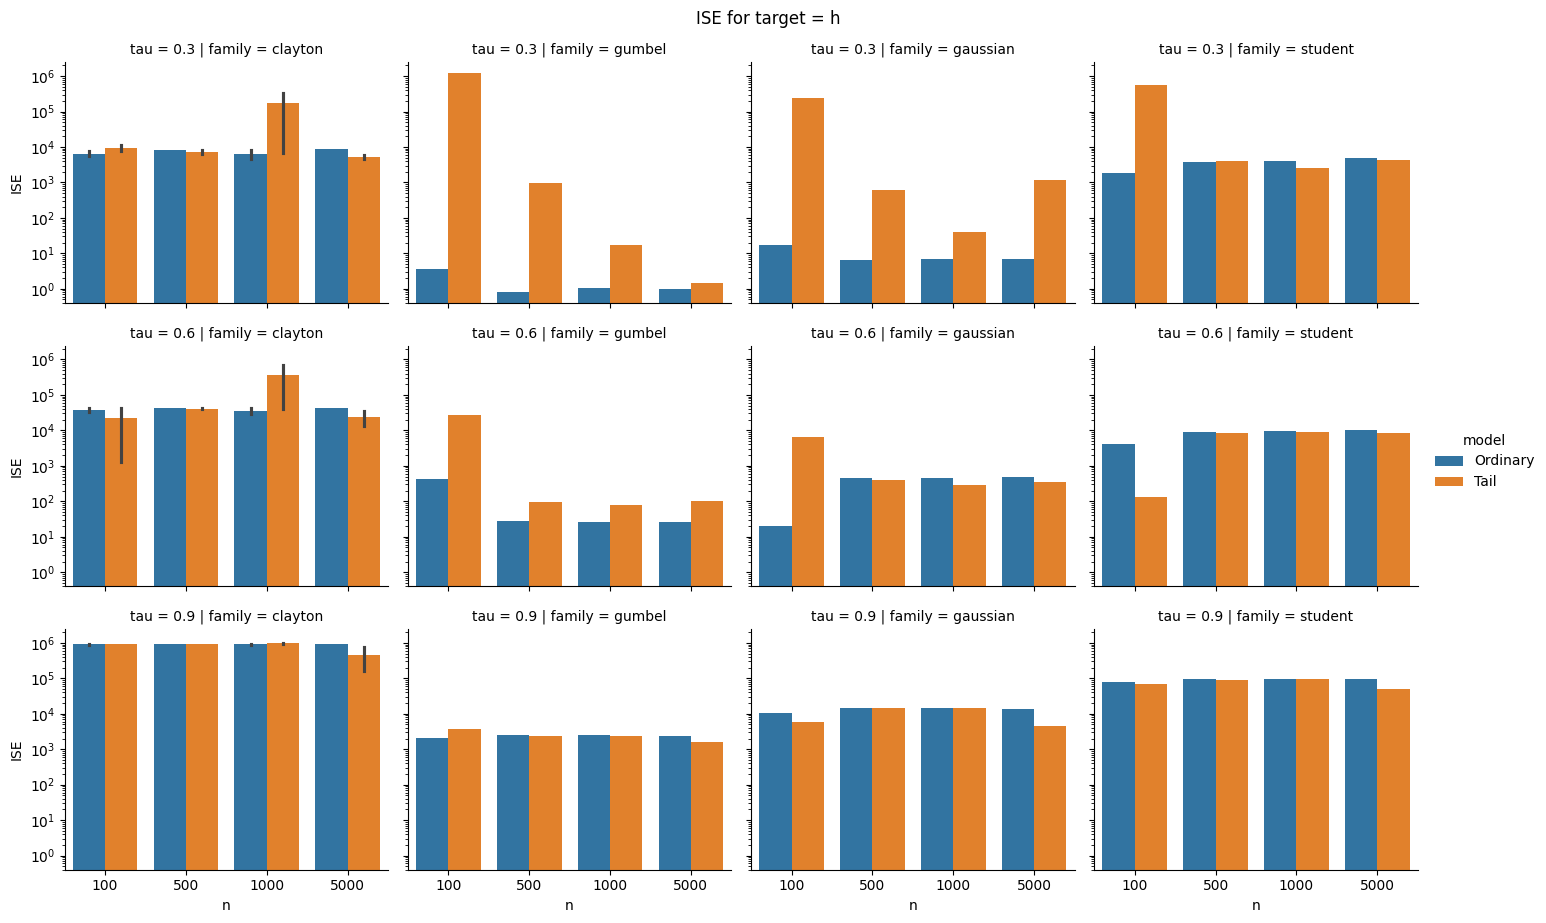

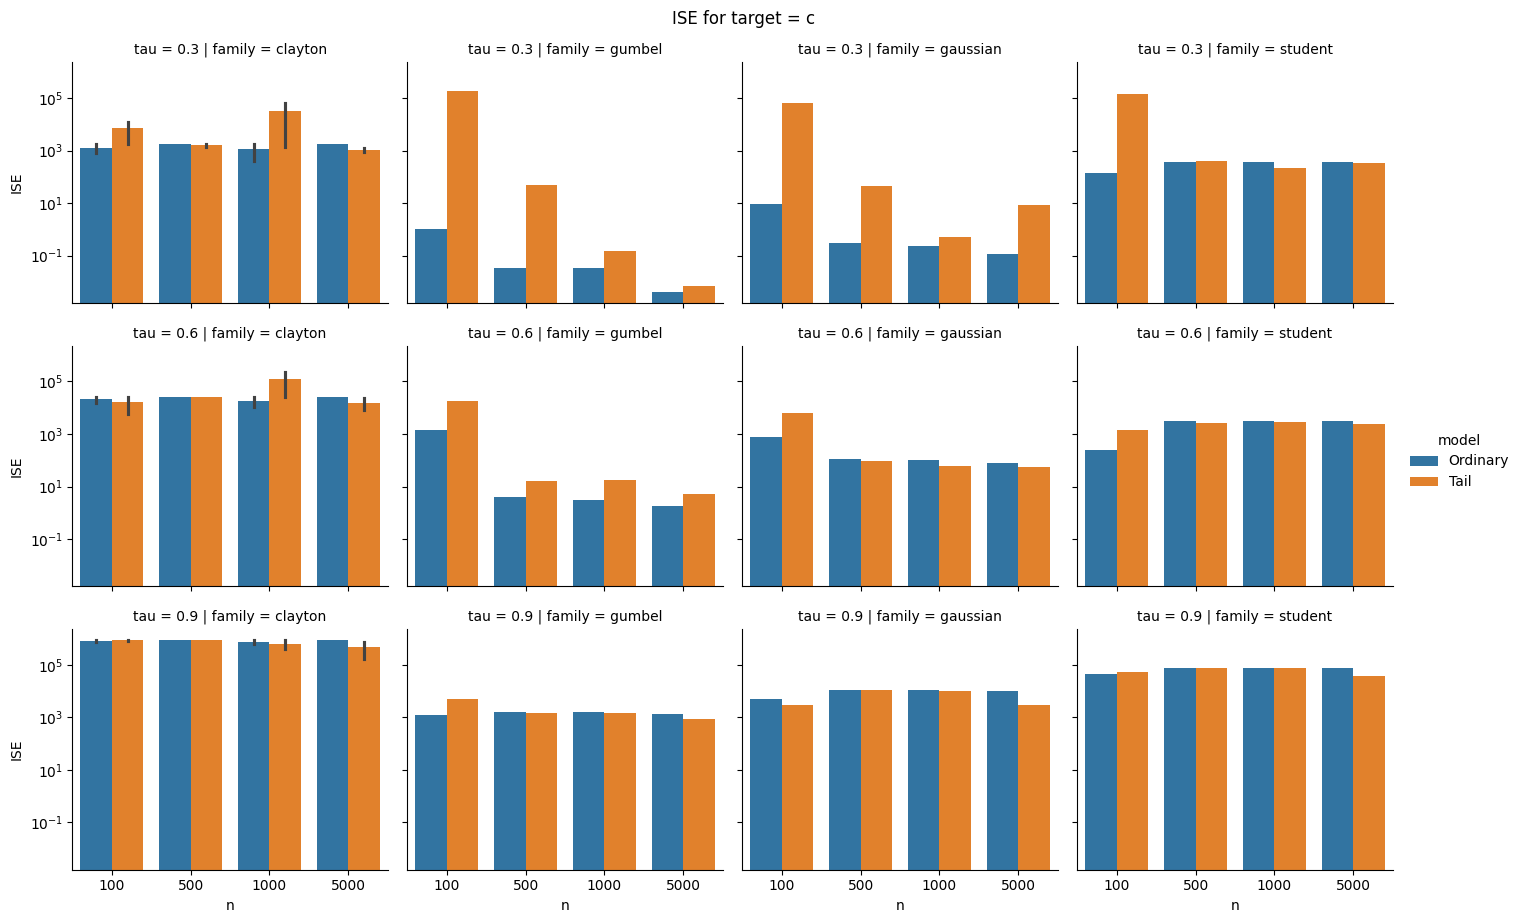

In [17]:
for target in ["r", "h", "c"]:
    target_df = metrics_df.query("target == @target")

    g = sns.catplot(
        data=target_df,
        x="n",
        y="ISE",
        hue="model",
        col="family",
        row="tau",
        kind="bar",
        height=3,
        aspect=1.2,
    )

    for ax in g.axes.flat:
        ax.set_yscale("log")

    g.fig.suptitle(f"ISE for target = {target}", y=1.02)
    plt.show()

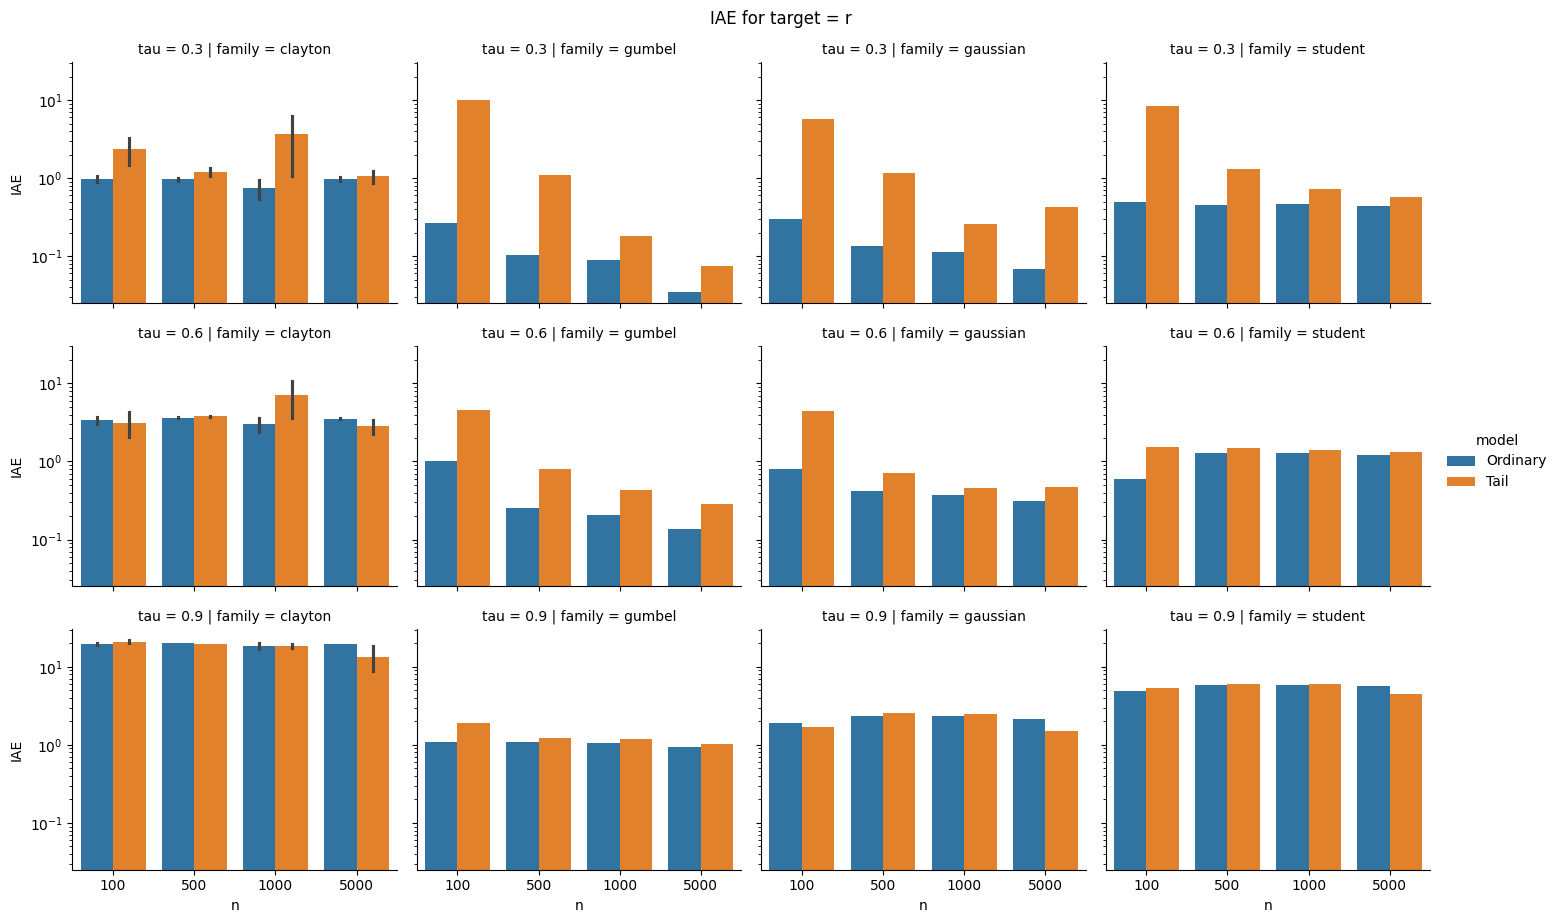

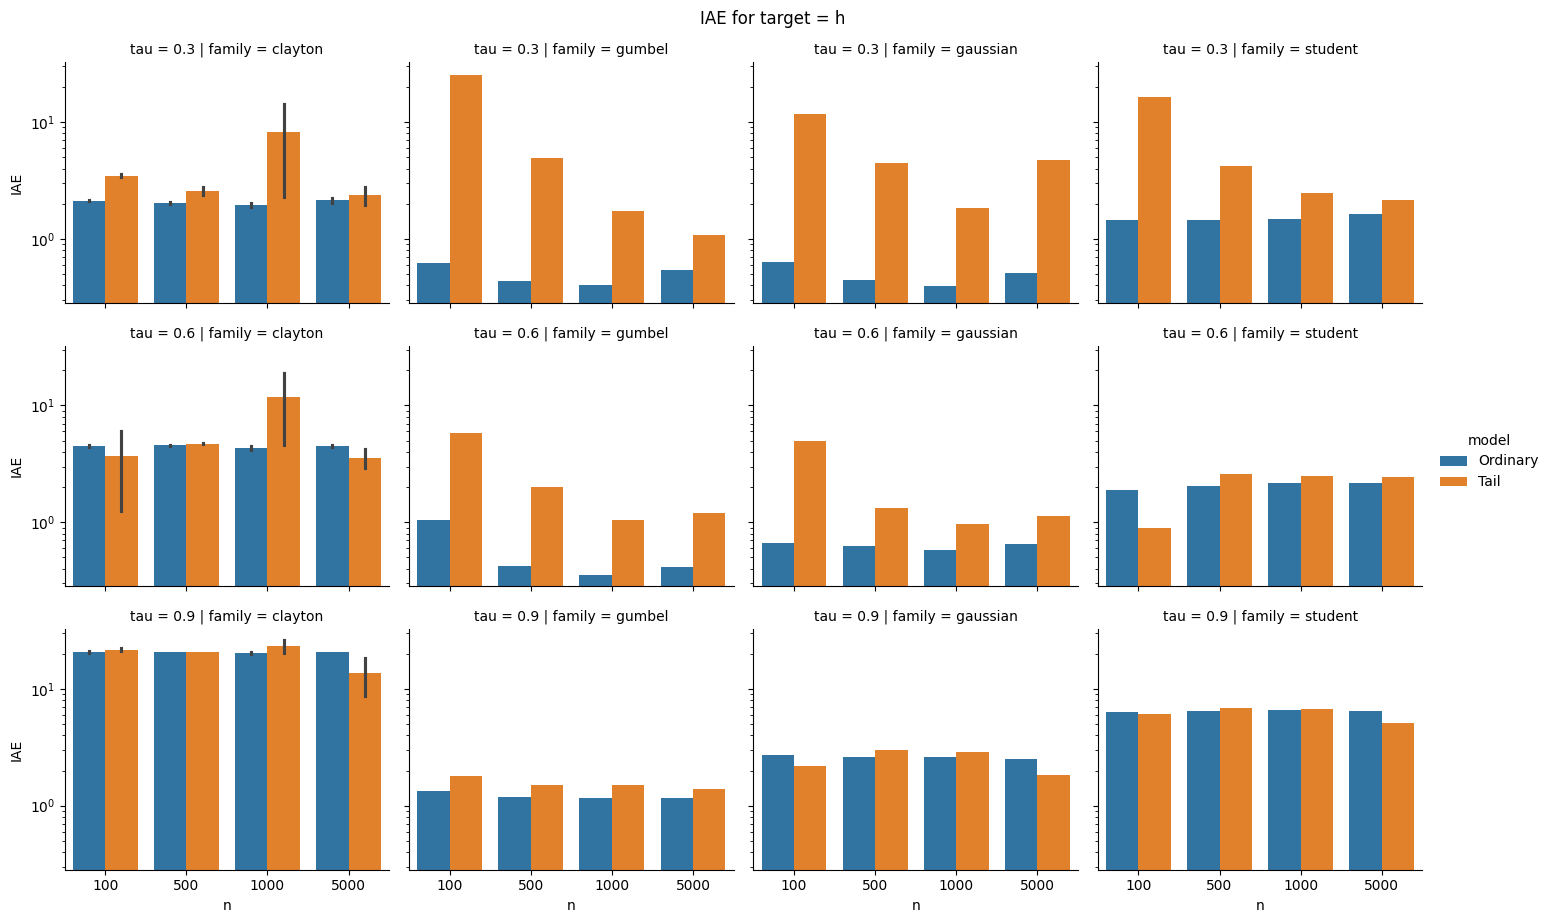

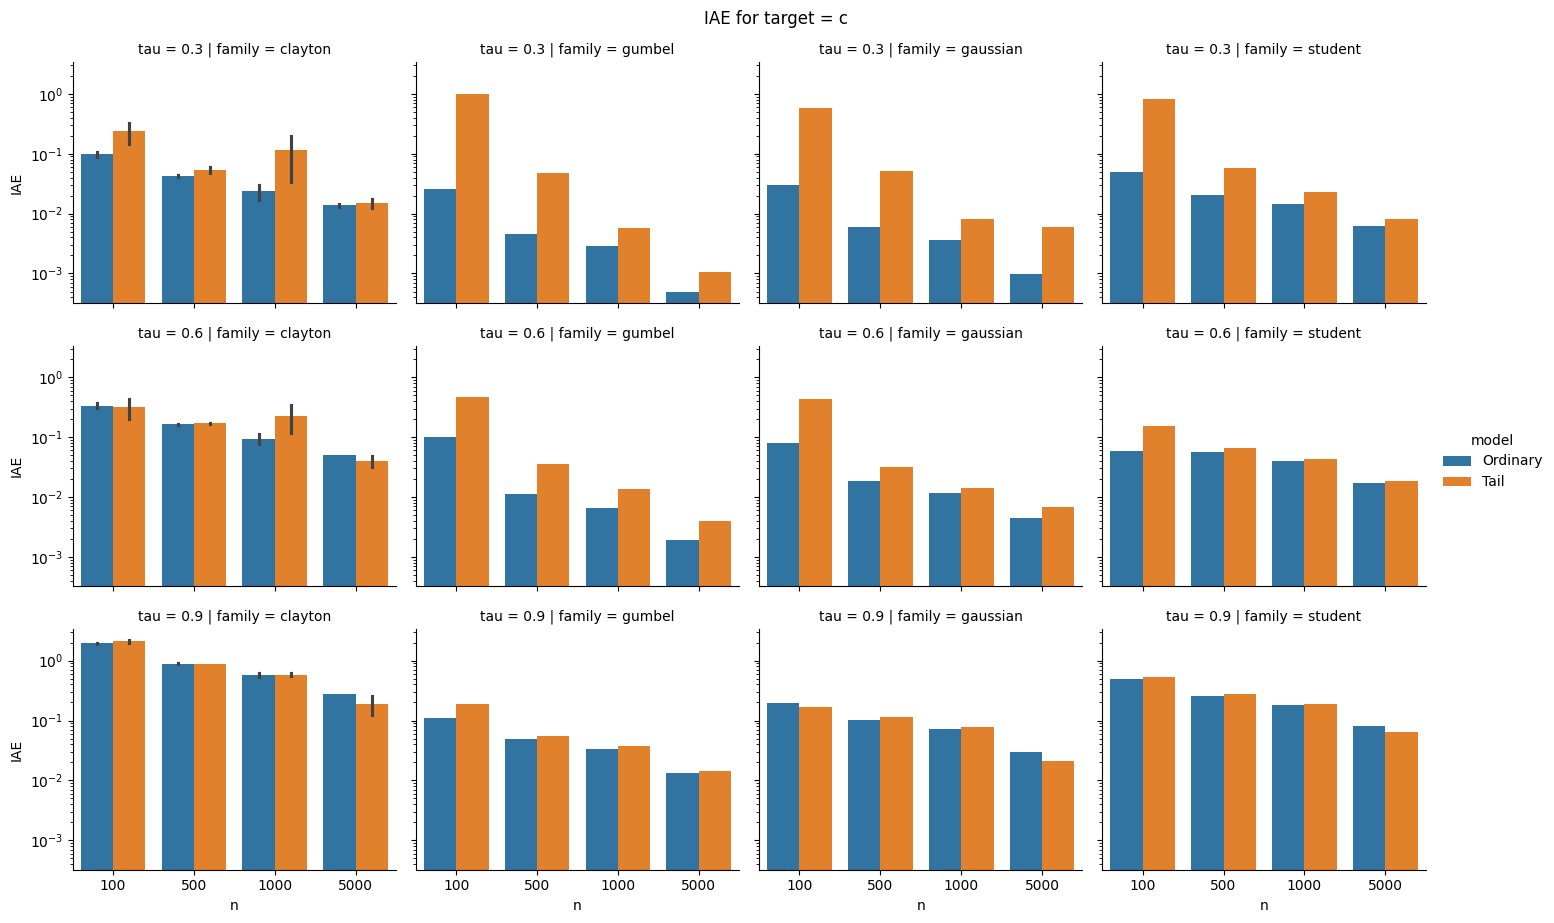

In [21]:
for target in ["r", "h", "c"]:
    target_df = metrics_df.query("target == @target")

    g = sns.catplot(
        data=target_df,
        x="n",
        y="IAE",
        hue="model",
        col="family",
        row="tau",
        kind="bar",
        height=3,
        aspect=1.2,
    )

    for ax in g.axes.flat:
        ax.set_yscale("log")

    g.fig.suptitle(f"IAE for target = {target}", y=1.02)
    plt.show()

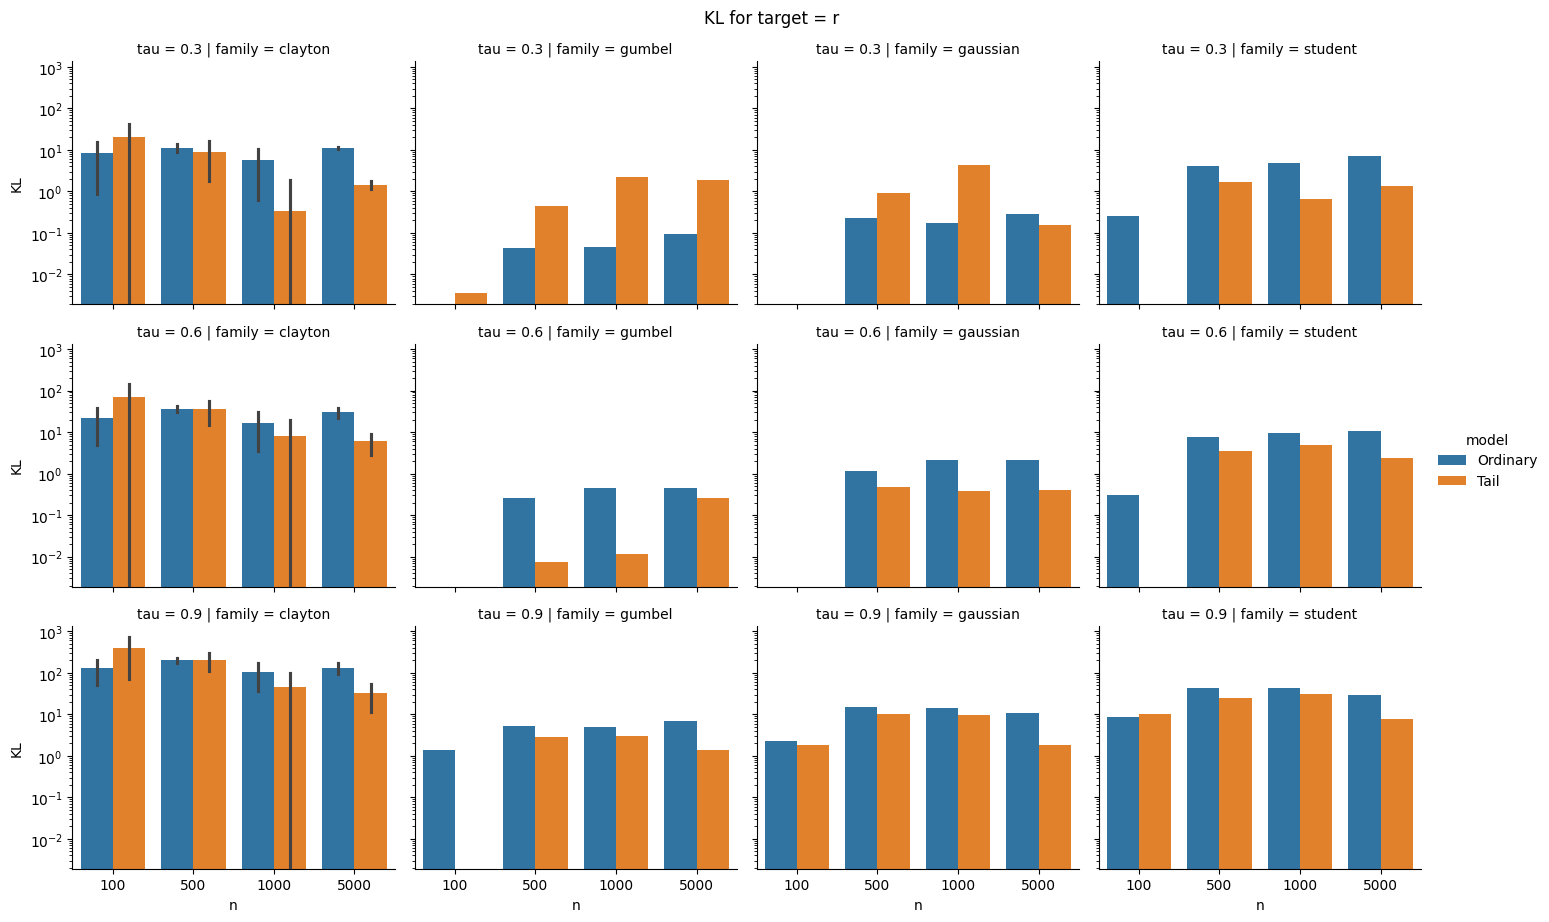

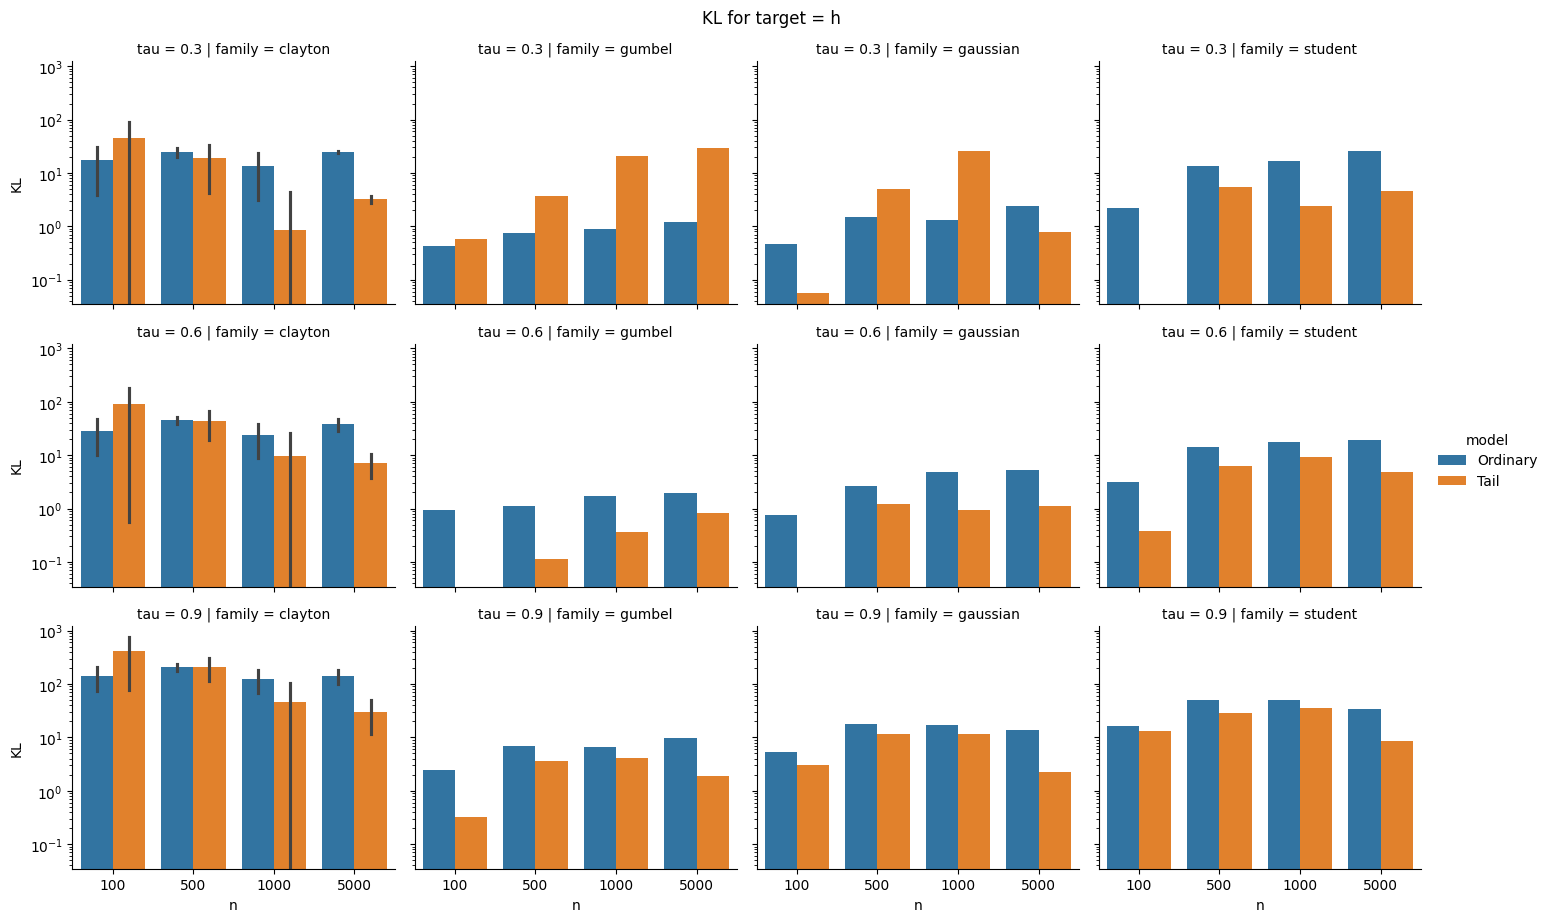

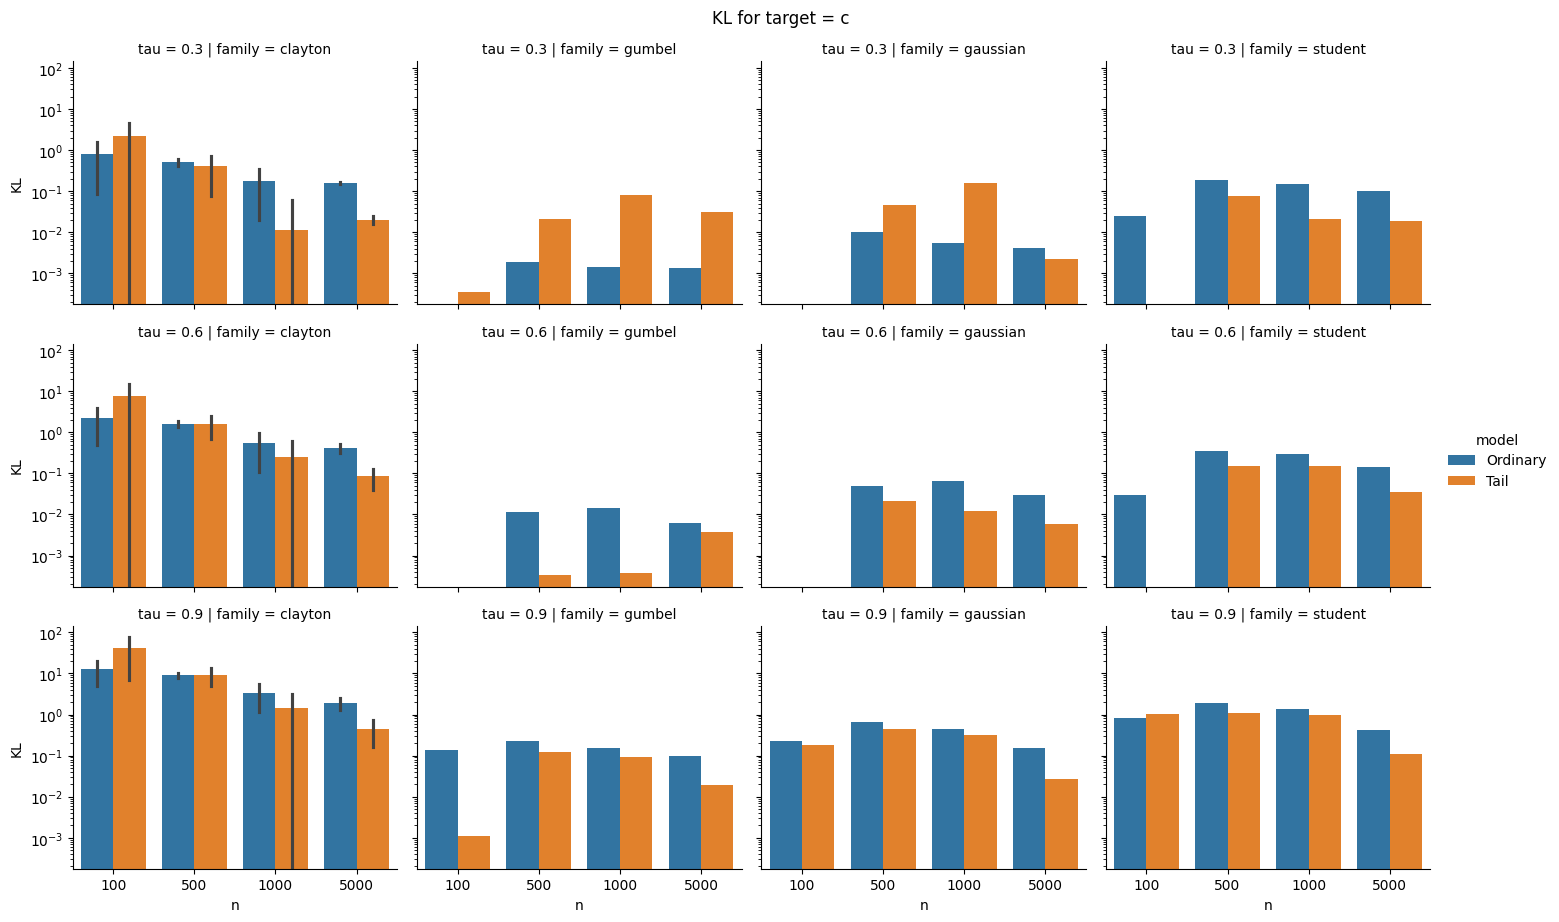

In [22]:
for target in ["r", "h", "c"]:
    target_df = metrics_df.query("target == @target")

    g = sns.catplot(
        data=target_df,
        x="n",
        y="KL",
        hue="model",
        col="family",
        row="tau",
        kind="bar",
        height=3,
        aspect=1.2,
    )

    for ax in g.axes.flat:
        ax.set_yscale("log")

    g.fig.suptitle(f"KL for target = {target}", y=1.02)
    plt.show()

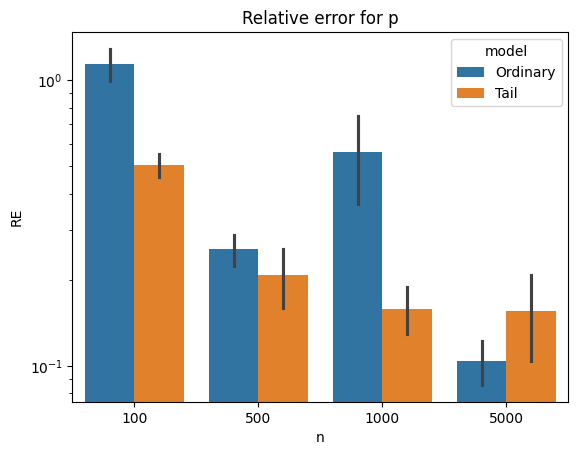

In [23]:
sns.barplot(data=p_df, x="n", y="RE", hue="model", errorbar="se")
plt.yscale("log")
plt.title("Relative error for p")
plt.show()